# Introduction to Bayesian Optimisation for ML

Bayesian optimisation is a technique for finding the optimal solutions for black-box problems with cost constraints where evaluations are said to be expensive. In machine learning, Bayesian optimisation is most often used for hyperparameter optimisation. In this context, the black-box function is the loss function of the model $\mathcal{L}$ and the parameters are its 


Bayesian optimisation has two components, the surrogate model and the acquistion function, which work hand-in-hand with each other. Typically, in a Bayesian optimisation problem, the black-box function has already been evaluated at a few points. Let us say that we known the value of the black-box function at $d$ number of points. Using these points, a surrogate model (function) is constructed with the aim of matching the black-box function as closely as possible. The acquisition function then uses this surrogate model to determine where to evaluate the black-box function next. This process continues iteratively, with each new evaluation updating the surrogate model and, in turn, the acquisition function. In this way, Bayesian optimisation balances exploitation (sampling where the surrogate predicts high objective values or low uncertainty) and exploration (sampling where the model is uncertain) in order to efficiently locate the optimum of the black-box function. The algorithm terminates once a predefined stopping criterion is met, such as a maximum number of function evaluations or convergence of the predicted optimum.

### Surrogate Models



A key aspect of the Bayesian optimisation is creation of a **surrogate model**. The purpose of a surrogate model is to approximate the unknown black-box functions given a finite number of evaluation points. In other words, the surrogate model emulates the black-box function based on its known, albeit, limited number of data points. A very common way to construct surrogate models is to use **Gaussian processes** (GPs). Another popular method is to use regression trees. Compared to GPs, regression trees have greater numerical stability and are also able to handle categorical variables. However, they do not have a native method of estimating uncertainty.  


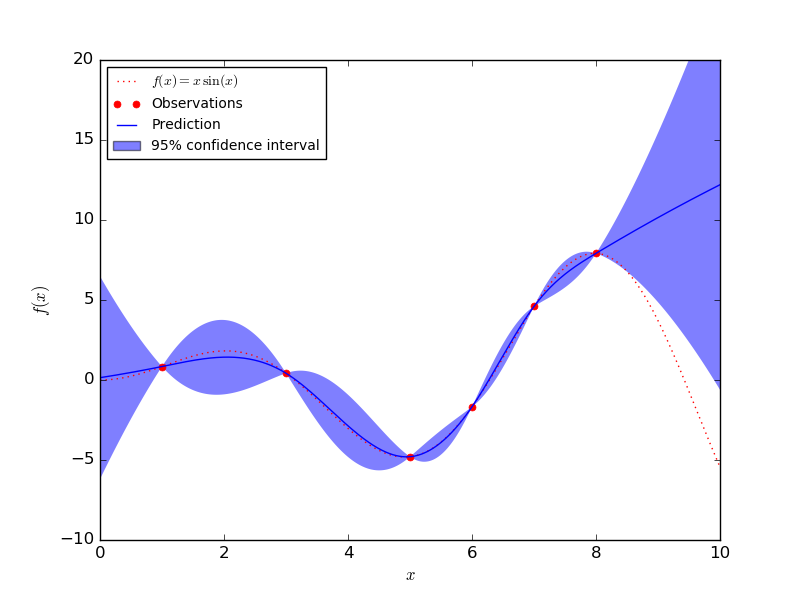

### Gaussian Processes 

GPs are a wide area of study, but when constructing a surrogate model, we are interested in Gaussian Process Regression (GPR). In GPR, we determine a family of all possible functions given a set of known points. There are two main components of GPR: the mean function $\mu(x)$ and the covariance kernel function $K(x, x')$. From a high-level view, the mean functon is the average function over all possible functions produced from the process while the kernel determines the interactions between the known points. More technically,

Using the sci-kit documentation, we fit a surrogate function to known data points generated from a black-box function using GPR with an RBF kernel: https://scikit-learn.org/stable/auto_examples/gaussian_process/plot_gpr_noisy_targets.html.

In [1]:
# Dependencies,
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
import matplotlib.pyplot as plt
import ipywidgets as widgets

# Hiding warnings,
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", message="Predicted variances smaller than 0. Setting those variances to 0.")
warnings.filterwarnings("ignore", category=ConvergenceWarning)

def true_function(x):
    """Simulated black-box function."""
    return -(1.4 - 3.0 * x) * np.sin(x)

def run_gpr(n_points):
    """Performs Gaussian process regression on the black-box function."""

    # Setting random seed,
    np.random.seed(42)

    # Evaluating the black-box function at random points,
    x = np.random.uniform(0, 10, (n_points, 1))
    y = true_function(x)

    y = y.ravel()
    kernel = kernel = 1 * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
    gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9)
    gpr.fit(x, y)

    #Create test points
    x_test = np.linspace(0, 10, 100).reshape(-1, 1)
    y_pred, std = gpr.predict(x_test, return_std=True)

    # Plotting,
    plt.figure(figsize=(10, 5))
    plt.plot(x_test, true_function(x_test), 'r:', label='True function')
    plt.scatter(x, y, c='k', label='Observations')
    plt.plot(x_test, y_pred, 'b-', label='Mean prediction')
    plt.fill_between(x_test.ravel(),
                    y_pred - 1.96 * std,
                    y_pred + 1.96 * std,
                    alpha=0.2, color='blue', label='95% confidence interval')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.title('Gaussian Process Regression with Your Dataset')
    plt.show()


# Creating slider,
slider = widgets.IntSlider(
    value=8,
    min=1,
    max=15,
    step=1,
    description='n_points:',
    continuous_update=False
)

widgets.interact(run_gpr, n_points=slider)

interactive(children=(IntSlider(value=8, continuous_update=False, description='n_points:', max=15, min=1), Out…

<function __main__.run_gpr(n_points)>

### Acquistion Functions



In order to determine where to evaluate the black-box function next, acquistion functions must balance exploration (sampling where there is large uncertainty according to the surrogate model) and exploitation (sampling in the neighbourhood where the black-box function is predicted to have large or small values). Some of the most common acquistion functions is are the Upper Confidence Bound (UCB) used for maximisation problems and the Lower Confidence Bound (LCB) for minimisation.

$$ \text{UCB}(x) = \mu(x) + \kappa \sigma (x) \qquad \text{LCB}(x) = \mu(x) - \kappa \sigma (x) $$

The $\kappa$ parameter balances the trade-off between exploration and exploitation with higher $\beta$ favouring more exploration over exploitation. Exploration favours sampling regions of the black-box function where surrogate model has a high uncertainty while exploitation samples in the neigbourhood where the black-box function has been shown have a high or low value (depending on whether we have a minimisation or a maximisation problem). In a maximisation problem, the next point of the black-block function to be evaluated is that which maximises the acquisition function such that, 

$$
x_{t+1} = \text{argmax}_x[\text{UBC}(x)]
$$

For minimisation problems we have the same, but with the negative of the LCB,

$$
x_{t+1} = \text{argmax}_x[-\text{LBC}(x)]
$$

As a rule of thumb, the maximmum of the acquisition function is assumed to be taken by convention. Another common acquisition function is the PI (probability of improvement) function. The PI function (for maximisation) can be written as,

$$
\text{PI}(x) = P(I(x) > 0)
$$

$P(I(x) > 0)$ is the probability that the improvement function $I(x) = f(x) - f(x^+) - \xi $ is positive at the point $x$, $x^+$ is the point at which the surrogate function $f$ has been shown to have the largest value so far in the optimisation process and $\xi$ is a parameter that controls the exploration/exploitation trade-off. Often we can write the PI function for maximisation as, 

$$
\text{PI}(x) = P(f(x) > f(x^+) + \xi)
$$

It then becomes more obvious that the PI function guides the optimisation process to evaluate at points which have a probability [...]. Specifically, for surrogate model contrsucted via GPR, the PI function has the following closed-form,

$$
PI(x) = \Phi \left( \frac{\mu(x) - f(x^+) - \xi}{\sigma(x)} \right) = \Phi(Z)
$$

In which, $\Phi$ is the standard cumulative normal distribution. Note that $\Phi(z)$ is a monotonic function with a domain $z \in ]-\infty,\infty[$. Let us assume that $\xi$ is large such that $\mu(x) - f(x^+) - \xi < 0$, to ensure that the magnitude $\mid Z \mid$ remains small such that the probability is large, the variance $\sigma$ must also be large. A large  variance signals a higher tendency for exploration as regions of the surrogate function with higher uncertainty are evalutated. The contrary is true when $\xi$ is small such that $\mu(x) - f(x^+) - \xi > 0$. Exploitation is preferred as $\mid Z \mid$ is large due to a large $\mu(x)$ and small $\sigma(x)$.